# Auswerten eines Fragebogens - Teil 3: Regression

In diesem Notebook werden die aus dem Fragebogen konstruierten Faktoren für Regressionsmodelle
verwendet. Im Mittelpunkt steht die explorative Innovation.

## Setup

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

import regression

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Datensatz einlesen
df = pd.read_csv("daten/CPlus-zFaktoren.csv")
df["ClusterNr"] = df["ClusterNr"].astype("category")
df.head()

,ExploitInno,ExploreInno,ProcessInno,FirmPerf,TrustInRegion,EnvironDyn,EnvironComp,Strategy,ClusterMgmt,AbsorpCap,ClusterNr,FirmAgeLog,FirmSizeLog,CommonFactor
0,-0.572867,-0.681673,0.542874,0.781280,1.248619,1.427318,0.458966,-2.351391,-1.313565,-0.078726,12,3.321928,4.321928,-0.029515
1,0.908263,1.180415,-0.618077,0.167111,1.055931,0.189850,-0.393758,1.247677,-1.165194,0.765965,12,2.321928,2.584963,0.714543
2,-0.424754,-0.108722,0.542874,-1.982481,0.477867,0.543413,-0.820120,0.047988,-0.868450,0.441084,12,3.459432,3.584963,0.256661
3,0.315811,0.607465,0.929858,0.781280,0.670555,1.073756,-0.393758,0.347910,1.505495,0.246155,12,2.000000,3.321928,0.972102
4,-0.276641,0.177753,0.155890,0.167111,-0.678262,0.543413,0.245785,0.347910,-0.423336,0.376108,12,4.754888,8.451211,0.428367


In [3]:
df.describe().round(3)

,ExploitInno,ExploreInno,ProcessInno,FirmPerf,TrustInRegion,EnvironDyn,EnvironComp,Strategy,ClusterMgmt,AbsorpCap,FirmAgeLog,FirmSizeLog,CommonFactor
count,242.000,249.000,247.000,215.000,250.000,257.000,255.000,250.000,218.000,241.000,257.000,254.000,255.000
mean,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,3.827,4.412,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.305,2.449,1.000
min,-3.091,-2.401,-1.779,-3.211,-2.605,-2.815,-2.526,-2.351,-2.055,-2.743,0.000,0.000,-2.891
25%,-0.425,-0.682,-0.812,-0.447,-0.630,-0.694,-0.607,-0.702,-0.868,-0.599,3.170,2.641,-0.573
50%,0.168,0.035,-0.038,-0.140,0.092,0.190,0.246,0.348,-0.052,0.051,4.000,4.248,0.142
75%,0.760,0.751,0.736,0.781,0.863,0.720,0.672,0.798,0.912,0.766,4.459,6.129,0.729
max,1.353,1.897,1.704,2.317,2.019,1.427,1.312,1.248,1.505,1.936,6.672,11.814,1.974


In [4]:
df.shape

(257, 14)

In [5]:
(df.isna().sum(axis=1) == 0).sum()

np.int64(154)

In [6]:
m1 = regression.fit_ols("ExploreInno ~ FirmAgeLog + FirmSizeLog", df)
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:            ExploreInno   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.285
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.104
Time:                        08:02:00   Log-Likelihood:                -345.86
No. Observations:                 246   AIC:                             697.7
Df Residuals:                     243   BIC:                             708.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.1828      0.200      0.914      

Ein sehr schwaches Modell. $R^2$ ist nur 0.02, also praktisch "Rauschen".

Zeigt sich auch bei F-Statistic: mit 2.3 bzw. p(F)=0.10 ist das Modell "nicht signifikant" unterschiedlich von einem Modell das nur den Mittelwert berechnet.

Der untere Block der `statsmodels`-Ausgabe enthält vor allem **Diagnosekennzahlen zu den Residuen** und zur numerischen Stabilität des Modells. Diese Werte sagen also weniger über die Stärke einzelner Vorhersagen aus, sondern darüber, ob wichtige Annahmen des OLS-Modells grob verletzt sein könnten.

**Omnibus** und **Jarque-Bera (JB)** sind Tests auf Normalverteilung der Residuen. Die zugehörigen p-Werte heißen **Prob(Omnibus)** und **Prob(JB)**. Ein kleiner p-Wert, zum Beispiel kleiner als 0.05, spricht dafür, dass die Residuen statistisch signifikant von einer Normalverteilung abweichen. Das ist vor allem für kleine Stichproben problematisch, weil t-Tests und Konfidenzintervalle dann weniger zuverlässig sein können. Bei größeren Stichproben ist OLS allerdings oft relativ robust gegenüber moderaten Abweichungen von der Normalverteilung. Deshalb sollte man diese Tests nicht isoliert interpretieren, sondern zusätzlich Residuenplots, Histogramme oder Q-Q-Plots betrachten.

**Skew** beschreibt die Schiefe der Residuenverteilung. Ein Wert nahe 0 bedeutet, dass die Residuen ungefähr symmetrisch verteilt sind. Negative Werte bedeuten eine linksschiefe Verteilung, positive Werte eine rechtsschiefe Verteilung. Als grobe Orientierung gelten Werte zwischen etwa -0.5 und +0.5 meist als unproblematisch; Werte außerhalb von ±1 deuten auf stärkere Schiefe hin.

**Kurtosis** beschreibt, wie stark die Verteilung der Residuen im Vergleich zur Normalverteilung zugespitzt ist bzw. wie schwer ihre Ränder sind. In der `statsmodels`-Ausgabe hat eine Normalverteilung ungefähr den Wert 3. Werte deutlich über 3 bedeuten stärkere Ausreißer bzw. schwerere Verteilungsränder. Werte deutlich unter 3 bedeuten eine flachere Verteilung mit weniger extremen Rändern.

**Durbin-Watson** prüft, ob die Residuen miteinander korreliert sind, also ob ein Fehlerwert systematisch mit dem nächsten zusammenhängt. Der Wert liegt ungefähr zwischen 0 und 4. Ein Wert nahe 2 spricht gegen Autokorrelation. Werte deutlich unter 2 deuten auf positive Autokorrelation hin, Werte deutlich über 2 auf negative Autokorrelation. Diese Kennzahl ist besonders wichtig bei Zeitreihendaten oder geordneten Beobachtungen. Bei normalen Querschnittsdaten, bei denen die Reihenfolge der Beobachtungen keine inhaltliche Bedeutung hat, ist Durbin-Watson meist weniger relevant.

**Cond. No.**, also die Condition Number, ist ein Hinweis auf mögliche numerische Probleme oder Multikollinearität. Kleine Werte sind unproblematisch. Sehr große Werte können darauf hinweisen, dass Prädiktoren stark miteinander zusammenhängen oder dass die Modellmatrix fast singulär ist. Als grobe Faustregel sind Werte unter 10 meist unkritisch, Werte über 30 können genauer geprüft werden, und sehr hohe Werte, etwa über 100 oder 1000, sind ein deutliches Warnsignal. In solchen Fällen sollte man Korrelationen, VIF-Werte und die Kodierung der Variablen überprüfen.

In [7]:
m2 = regression.fit_ols("ExploreInno ~ FirmAgeLog + FirmSizeLog + EnvironDyn + EnvironComp + AbsorpCap", df)
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:            ExploreInno   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     42.05
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           1.66e-30
Time:                        08:02:00   Log-Likelihood:                -252.26
No. Observations:                 232   AIC:                             516.5
Df Residuals:                     226   BIC:                             537.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.1826      0.155      1.180      

Erste Interpretation: je dynamischer ein Markt, desto mehr betreiben Firmen explorative Innovation.
Stärkere Konkurrenz wirkt im Modell negativ, bessere Absorptionsfähigkeit positiv. Da unabhängige
Variablen untereinander korrelieren können, sind isolierte oder kausale Interpretationen nicht zulässig.

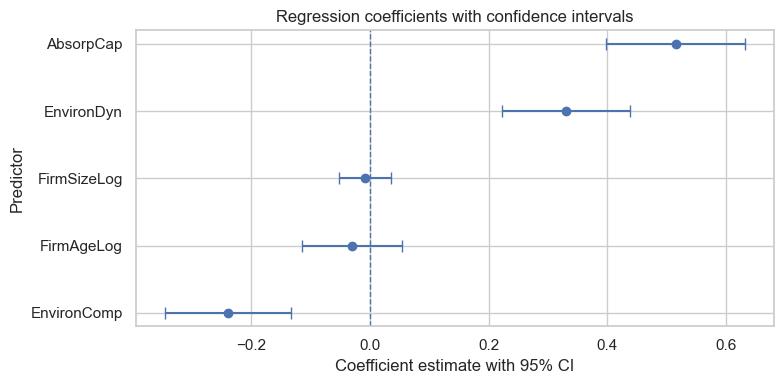

In [8]:
regression.plot_coef(m2)

In [9]:
# Schauen wir uns im Gegenzug die exploitative, also inkrementelle, Innovation an.

m3 = regression.fit_ols("ExploitInno ~ FirmAgeLog + FirmSizeLog + EnvironDyn + EnvironComp + AbsorpCap", df)
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:            ExploitInno   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     66.38
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           5.61e-42
Time:                        08:02:00   Log-Likelihood:                -216.23
No. Observations:                 225   AIC:                             444.5
Df Residuals:                     219   BIC:                             465.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.0935      0.139     -0.672      

Die Absorptionskapazität hat wieder einen sehr starken positiven Einfluss darauf, auch die Dynamik des Umfeldes. Spannenderweise ist es nun so, dass der Konkurrenzdruck sich positiv auf die inkrementelle Innovation auswirkt. Bei der explorativen Innovation war der Konkurrenzdruck hemmend.

Mögliche Gründe dafür sind:

- inkrementelle Innovation birgt geringeres Risiko, das heißt der Einsatz von Kapital ist leichter zu rechtfertigen.
- inkrementelle Innovation zeitigt frühere Ergebnisse, das heißt, ein postiver ROI (Return on Investment) ist deutlich schneller erreichbar
- Firmen befinden sich bei starker Konkurrenz in einem Verdrängungswettbewerb, der hauptsächlich über Preis und weniger über neue Produkte dominiert wird.
- ...

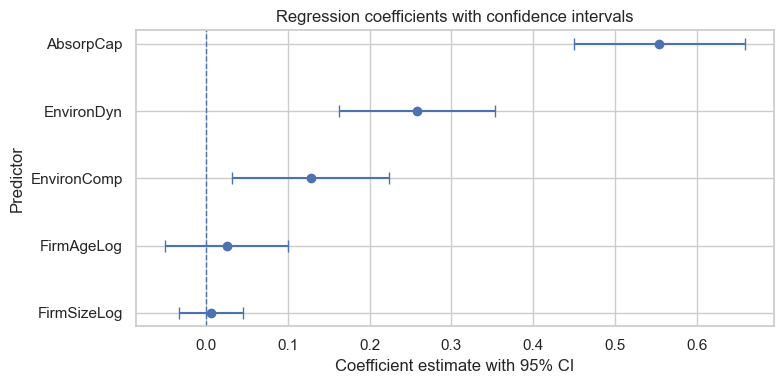

In [10]:
regression.plot_coef(m3)

### Testen des Common Method Bias

Da alle unsere Variablen aus dem selben Messinstrument stammen, nämlich dem Fragebogen, kann es sein, dass dieser einen systematischen Bias (Tendenz/Präferenz/Neigung) enthält.

Um das zu testen, nehmen wir den `CommonFactor` mit in die Regression auf. Der `CommonFactor` enthält alle Items unseres Fragebogens.

Wir erwarten, dass
- das R² (erklärte Varianz) nicht sonderlich steigt und
- die Regressions-Koeffizienten mit dem Modell ohne `CommonFactor` vergleichbar sind.

Wenn das Hinzufügen des CommonFactors das R² nur geringfügig erhöht und die ursprünglichen Koeffizienten weitgehend stabil bleiben, gibt es keinen starken Hinweis darauf, dass die Ergebnisse wesentlich durch Common Method Bias verzerrt sind. Ein Beweis, dass kein Bias vorliegt, ist das aber nicht.

In [11]:
m3b = regression.fit_ols("ExploitInno ~ FirmAgeLog + FirmSizeLog + EnvironDyn + EnvironComp + AbsorpCap + CommonFactor", df)
print(m3b.summary())

                            OLS Regression Results                            
Dep. Variable:            ExploitInno   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     57.53
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           2.75e-42
Time:                        08:02:00   Log-Likelihood:                -213.23
No. Observations:                 225   AIC:                             440.5
Df Residuals:                     218   BIC:                             464.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0566      0.138     -0.409   

$R^2$ ist nicht deutlich gestiegen, d.h. im `CommonFactor` steckt (in Kombination mit den anderen Variablen) wenig neue Information. Gut

Aber: Der Koeffizient der Absorptionskapazität hat sich deutlich verändert. Ist das darauf zurückzuführen, dass wir einen Bias haben? Oder steckt etwas anderes hinter diesem Phänomen?

Auffällig ist, dass nach Aufnahme des `CommonFactor` der Standardfehler von `AbsorbCap` stark zunimmt.

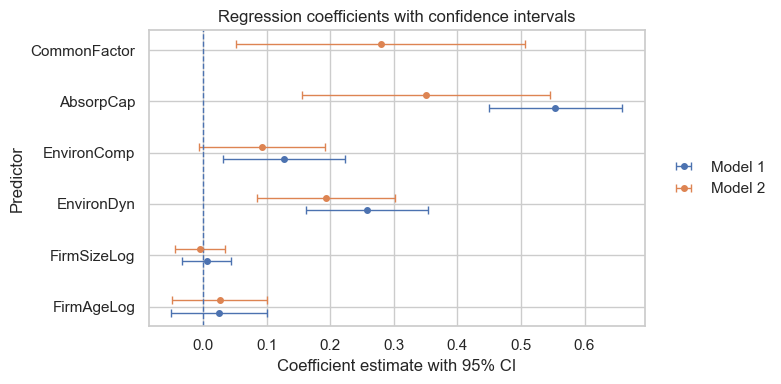

In [12]:
regression.plot_coef_compare([m3, m3b])